## Load Functions

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import time

In [2]:
def Marchenko_Pastur_significance_threshold(lam,var):
    sqrt = np.sqrt(lam)
    out1 = var*(1-sqrt)**2
    out2 = var*(1+sqrt)**2
    return (out1,out2)
    
def Marchenko_Pastur_distribution(lambda_min,lambda_max,lam,var):
    x_vector = np.linspace(lambda_min,lambda_max,10000)
    dx = x_vector[1]-x_vector[0]
    pdf = 1/(2*np.pi*var) * np.sqrt((lambda_max-x_vector)*(x_vector-lambda_min))/(lam*x_vector)
    return x_vector,pdf

In [3]:
def plot_matrix(matrix,cmap = 'RdBu',max_value=None,min_value=None,aspect=None,tight_layout=True,figsize=None,
               xticks = [],x_ticklabels = [],x_orientation=0,x_alignment='center',
                yticks = [],y_ticklabels = [],title=None,
               xlabel=None,ylabel=None,
                set_log_xscale=False,set_log_yscale=False,scale=None,
               cbar_label = None,x_fontsize=10,y_fontsize=10,
               savefig=False,format='png',out_dir='',data_name = '',
               draw_special_diagonal=False,diagonal_color='k'):

    if max_value==None:
        max_value = 1.1*np.max(matrix)
    if min_value==None:
        min_value = 1.1*np.min(matrix)
    norm_value = (colors.TwoSlopeNorm(vcenter=0,vmin=min_value,vmax=max_value) if cmap=='RdBu' else None)
    if scale=='log': norm_value='log'
    fig,ax = plt.subplots(figsize=figsize)
    heatmap = ax.imshow(
               matrix,
               cmap=cmap,
               aspect=aspect,
               norm=norm_value,
               vmax = (max_value if cmap=='Reds' or cmap=='Blues' else None),
                       )
    cbar = fig.colorbar(heatmap,label=cbar_label)
    if draw_special_diagonal ==True:
        for i in range(min(np.shape(matrix)[0],np.shape(matrix)[1])):
            rect = patches.Rectangle(
                (i - 0.5, i - 0.5),  # bottom-left corner (cell boundaries in imshow coordinates)
                1, 1,                # width, height (one cell)
                facecolor="black",
                edgecolor="none",
                zorder=3             # draw above the image
            )
            ax.add_patch(rect)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_yticklabels(y_ticklabels,fontsize=y_fontsize)
    ax.set_xticklabels(x_ticklabels,rotation=x_orientation,ha=x_alignment,
                      fontsize=x_fontsize)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if set_log_xscale == True:
        ax.set_xscale('log')
    if set_log_yscale==True:
        ax.set_yscale('log')
    if tight_layout==True:
        plt.tight_layout()
    if savefig==True:
        plt.savefig(os.path.join(out_dir,data_name)+str('.{}'.format(format)),format=format,dpi=300,transparent=True)
    plt.show()  

    return

In [4]:
from numba import njit

@njit
def species_growth_rates(R_vec,n_vec,
                 growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                ):
    ''' Growth of the species as a function of the resource abundances: g_i^\alpha(\vec{R},\vec{n})
    By default, we use nR/(1+R) on all resources.
    '''
    R_part = R_vec/(1+R_vec)
    outer = np.outer(R_part,n_vec) #Shape (N_R,N_n)
    outer = outer*growth_choices
    
    # if np.random.random()<1e-3:
    #     print('growth_rates',np.sum(outer>1e-3))
    #     print(outer[0,:])

    ''' Calculate also the total species growth rates '''
    species_total_growth_rate = np.sum(outer,axis=0) #shape (N_species)
    return outer,species_total_growth_rate

@njit
def resource_depletion_production(R_vec,n_vec,
                   total_species_growth_rate, #Shape (N_species)
                                  inv_yields):

    '''
    Calculates g_i^alpha*1/Y_i^\alpha
    '''

    resource_changes = total_species_growth_rate[None,:]*inv_yields #is shape (1,N_res,N_species). I don't know why there is the one

    # if np.random.random()<1e-3:
    #     print('production terms',resource_changes)
    
    return resource_changes

@njit
def d_resources(R_vec,n_vec,
               entry_rates,
                total_growth_rates,
                inv_yields):

    entry = entry_rates #shape (N_res)
    res_changes = resource_depletion_production(R_vec,n_vec,total_growth_rates,inv_yields)

    # if np.random.random()<1e-3:
    #     print('res_changes',res_changes)

    consumption_production = -np.sum(res_changes,axis=1) #Shape N_resource

    return entry+consumption_production

@njit
def d_species(n_vec,growth_rates):

    species_growth = np.sum(growth_rates,axis=0)

    return species_growth    
    
    
    
    

In [5]:
dataset_name = '0'
if os.path.exists(dataset_name)==False:
    os.mkdir(dataset_name)

In [6]:
''' System constants '''
N_species = 20
N_resources = 1
independent_species_cutoff = 20 #N_species #species beyond this cutoff exist independently of all others and are akin to noise
nsteps = 30000
dt = 0.005
dilution = 0.1

inv_yields = np.ones(N_species)
sigmas = np.linspace(1e-4,10,100) #linear sigma
# sigmas  = np.logspace(-4,1,100,base=10)


set_random_seed = True
if set_random_seed:
    np.random.seed(0)

In [192]:
nsteps = 100000

if which_option!='A': print('You did not select this option!'); 
else:
    species_abus = np.random.random(N_species)
    resource_abus = np.random.random(N_resources)
    
    res_noise_weights = 1e-5#np.linspace(1e-5,1e-1,N_resources) #this way there are different noise levels for different resource-mediated interactions
    
    
    species_traces_full = []
    resource_traces_full = []

    # ''' Resource entries '''
    # entry_rates = np.zeros(N_resources)
    # entered_res = np.random.choice(independent_species_cutoff,size=5,replace=False)
    # entry_rate_sigma = 10
    # entry_rates[entered_res] = np.abs(np.random.normal(0,entry_rate_sigma,size=len(entered_res))) #gaussian(0,1) 
    # entry_rates[independent_species_cutoff:] = np.abs(np.random.normal(0,entry_rate_sigma,size=N_species-independent_species_cutoff))#such that independent species also grow, in the absence of interactions with others.

    
    # ''' Prepare colored noise ''' 
    # sigma_outside = 0.1*entry_rate_sigma
    # sigma_inside = 0.1*entry_rate_sigma
    # outside_resource_noise_prev = np.random.normal(0,sigma_outside,size=(N_resources))*np.sqrt(dt)*(entry_rates>0) #noise for supplied resources is large
    # inside_resource_noise_prev = np.random.normal(0,sigma_inside,size=(N_resources))*np.sqrt(dt)*(entry_rates<1e-10) #noise for cross-fed resources is small
    # tau = 0.0001#autocorrelation time of the resource noise

    ''' Resource entries. Supplied resources are always the same, but their entry rates are random. '''
    entry_rates = np.zeros(N_resources)
    # entered_res = np.random.choice(min(N_resources,independent_species_cutoff),size=N_resources,replace=False)
    # entered_res = [7,13,14,18,19]
    if dataset_name == 'single_resource_high_fluctuation':
        entered_res = np.array([0])
    elif dataset_name == 'two_resources_one_high_one_low':
        entered_res = np.array([0,1])
    else:
        entered_res = np.random.choice(N_resources,size=how_many_supplied_resources-1,replace=False)
        entered_res = np.concatenate(([0],entered_res)) #always supply resource 0 to avoid having unused resources.
    # entry_rate_sigma = 1
    # entry_rate_mean = entry_rate_sigma
    entry_rate_mean = 2 #From 2025.10.17.4:02pm
    entry_rate_sigma = entry_rate_mean

    ### For CR-batch-like simulations ###
    # entry_rates = np.random.random(3)*10
    # entry_rates[2] = 0
    print('entry_rates',
          entry_rates)

    
    ### Truncated gaussian entry rate
    # entry_rates[entered_res] = np.abs(np.random.normal(entry_rate_mean,entry_rate_sigma,size=len(entered_res))) #gaussian(0,1) 
    # if independent_species_cutoff<N_resources:
    #     entry_rates[independent_species_cutoff:] = np.abs(np.random.normal(entry_rate_mean,entry_rate_sigma,size=N_resources-independent_species_cutoff))
    ### Entry rates sampled from uniform
    entry_rates[entered_res] = np.random.random(size=len(entered_res))*10
    ### Same entry rate for all
    # entry_rates[entered_res] = entry_rate_mean
    

    
    # fig,ax = plt.subplots() #is ok
    # ax.bar(np.arange(len(entry_rates)),entry_rates)
    # plt.show()

    
    print('enterd res.',entered_res)
    print('PID',os.getpid(),entry_rates[0])
    
    species_abus = np.random.random(N_species)
    # For CR-batch-like simulations. Start species in group 1 and 2 at higher abundances than species in group 3
    species_abus[:7] *= 10
    species_abus[7:14] *= 10
    species_abus[14:] *= 0.2
    resource_abus = np.random.random(N_resources)
    

    time0 = time.time()


    ''' Prepare colored noise ''' 
    sigma_outside = 1 #From 2025.10.17.4:01pm
    sigma_inside = 1
    outside_resource_noise_prev = np.random.normal(0,sigma_outside,size=(N_resources))*np.sqrt(dt)*(entry_rates>0) #noise for supplied resources is large
    inside_resource_noise_prev = np.random.normal(0,sigma_inside,size=(N_resources))*np.sqrt(dt)*(entry_rates<1e-10) #noise for cross-fed resources is small
    tau = 0.000001#autocorrelation time of the resource noise

    
    for step in range(nsteps):
        if step%1000==0: print('{:.3f}%'.format(step/nsteps*100))
        species_traces_full.append(np.copy(species_abus))
        resource_traces_full.append(np.copy(resource_abus))
        
    
        
        ''' Growth rates '''
        growth_rates,total_growth_rate_per_species = species_growth_rates(resource_abus,species_abus,
                     growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                    )
        
        
        # if np.random.random()<1e-3: print('growth_rates',growth_rates[0,:])
        
        d_res = d_resources(resource_abus,species_abus,
                   entry_rates,
                            total_growth_rate_per_species,
                   inv_yields)-resource_abus*dilution
        # if step%100==0:
        #     # print('growth_rates',total_growth_rate_per_species[10:15],total_growth_rate_per_species[50:55])
        #     # print('entry_rates \n',#growth_rates[10:15,10:15],'\n',
        #     #       entry_rates[50:55])
        #     # print('total_growth_rate \n',#growth_rates[10:15,10:15],'\n',
        #     #       growth_rates[50:55,50:55])
        #     print('resource_depletion_production \n',
        #           resource_depletion_production(resource_abus,species_abus,total_growth_rate_per_species,inv_yields)[10:25,10:25])
            
                
        # if np.random.random()<1e-3: 
        #     # print('d_res',d_res); 
        #     print('d_resources',d_resources(resource_abus,species_abus,
        #            entry_rates,growth_rates,inv_yields))
        
        d_sp = d_species(species_abus,growth_rates)-species_abus*dilution
        sp_noise = np.random.normal(0,1,size=(N_species))*np.sqrt(dt)
        
        species_abus += d_sp*dt +sp_noise

                  

        thres = 1e-10
        ''' Time-correlated noise '''
        # outside_resource_noise = (np.exp(-dt/tau)*outside_resource_noise_prev
        #     +np.sqrt(1-np.exp(-2*dt/tau))*np.random.normal(0,sigma_outside,size=(N_resources)))*np.sqrt(dt)*(entry_rates>=thres) #noise for supplied resources is large
        # inside_resource_noise = (np.exp(-dt/tau)*inside_resource_noise_prev
        #     +np.sqrt(1-np.exp(-2*dt/tau))*np.random.normal(0,sigma_inside,size=(N_resources)))*np.sqrt(dt)*(entry_rates<thres) #noise for cross-fed resources is small
        
        ''' WHite noise '''
        outside_resource_noise = np.random.normal(0,sigma_outside,size=(N_resources))*np.sqrt(dt)*(entry_rates>=thres) #noise for supplied resources is large
        inside_resource_noise = np.random.normal(0,sigma_inside,size=(N_resources))*np.sqrt(dt)*(entry_rates<thres) #noise for cross-fed resources is small
        
        
        outside_resource_noise[resource_abus<thres] = 0
        inside_resource_noise[resource_abus<thres] = 0

        # if step%100==0:
        #     print('inside_res_noise \n',
        #           inside_resource_noise[50:55],'\n',
        #           'outside_resource_noise \n',
        #           outside_resource_noise[50:55])
        
        # if step%100==0:
        #     # print('growth_rates',total_growth_rate_per_species[10:15],total_growth_rate_per_species[50:55])
        #     print('d_species',d_species(species_abus,growth_rates)[10:15],d_species(species_abus,growth_rates)[50:55])
            
        #     print('d_res',d_res[10:15],d_res[50:55])
        
        resource_abus += d_res*dt+outside_resource_noise+inside_resource_noise
        resource_abus[resource_abus<thres] = 0
        species_abus[species_abus<thres] = 0

        outside_resource_noise_prev = outside_resource_noise
        inside_resource_noise_prev = inside_resource_noise
    
    inv_yields_complete = np.copy(inv_yields)
    growth_choices_complete = np.copy(growth_choices)

NameError: name 'which_option' is not defined

In [196]:
supplied_resources = np.copy(entered_res)
print(supplied_resources)

[0 1]


In [197]:

resource_traces_full = np.array(resource_traces_full)
species_traces_full = np.array(species_traces_full)

[0 1]
[0.00331903 0.00287589]


Text(0, 0.5, 'n')

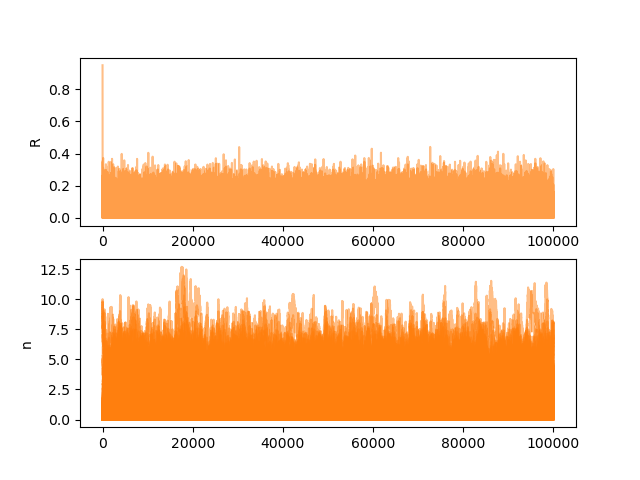

In [198]:
plt.close('all')
%matplotlib widget
fig,ax = plt.subplots(2,1)
# ax[0].plot(resource_traces_full[:,[50,51,52]])
for res in range(N_resources):
    if res in entered_res:
        ax[0].plot(resource_traces_full[:,res],'tab:orange',alpha=0.5)
    else:
        ax[0].plot(resource_traces_full[:,res],'tab:blue',alpha=0.5)
res_vars = np.var(resource_traces_full[-10000:,:],axis=0)
print(entered_res)
print(res_vars)
ax[0].set_ylabel('R')
# ax[1].plot(species_traces_full)
for s in range(N_species):
    if np.sum(inv_yields[entered_res,s])>0: #species consumes entered resource
        ax[1].plot(species_traces_full[:,s],'tab:orange',alpha=0.5)
    else:
        ax[1].plot(species_traces_full[:,s],'tab:blue',alpha=0.5)
ax[1].set_ylabel('n')
# ax[1].set_yscale('log')
# ax[0].set_yscale('log')

In [40]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection


if 'CR_batch' in dataset_name:
    projections = inv_yields[2,:][None,:]*(species_traces_full-np.mean(species_traces_full,axis=0))
    (N1,N2,N3) = (np.sum(projections[:,:N_species//3+1],axis=1),
                  np.sum(projections[:,N_species//3+1:2*(N_species//3)+1],axis=1),
                  np.sum(projections[:,2*(N_species//3)+1:],axis=1))

# Stack points
points = np.array([N1[::10], N2[::10], N3[::10]]).T

# Create line segments
segments = np.concatenate(
    [points[:-1, None, :], points[1:, None, :]],
    axis=1
)

# Color parameter (from 0 to 1)
t = np.linspace(0, 1, len(segments))

# Create the 3D line collection
lc = Line3DCollection(segments, cmap='coolwarm',)
lc.set_array(t)
lc.set_linewidth(2)


normal = np.array((1,1,1))
xx, yy = np.meshgrid(range(-40,40), range(-40,40))
d=0
z = (-normal[0] * xx - normal[1] * yy - d) * 1. /normal[2]

%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(xx, yy, z, alpha=0.2)
# ax.plot(N1,N2,N3,)
ax.add_collection(lc)
cbar = fig.colorbar(lc, ax=ax, pad=0.1)
cbar.set_label('Time (a.u.)')

ax.set_xlim(-40,40)
ax.set_ylim(-40,40)
ax.set_zlim(-40,40)

NameError: name 'N1' is not defined

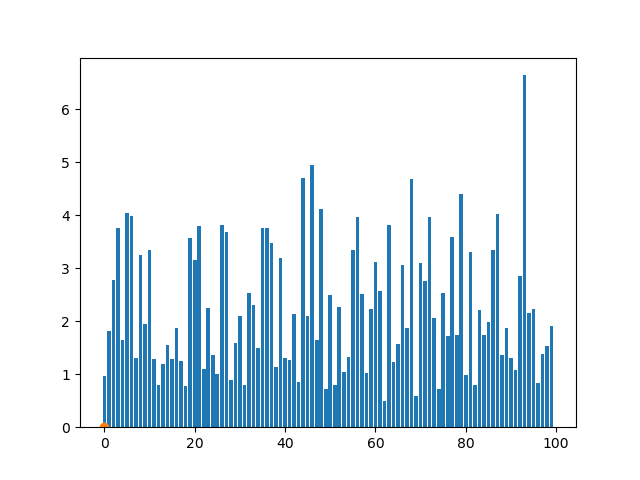

In [41]:
fig,ax = plt.subplots()
ax.bar(np.arange(N_species),
       np.mean(species_traces_full[-1000:,:],axis=0))
ax.scatter(np.arange(N_resources)[entry_rates>0]*5,[0]*len(supplied_resources))
# ax.set_yscale('log')

In [189]:
''' Plot abundances of cross-fed species pairs to check, by eye, if they are correlated or not '''
species_that_feed_on_external_resources = np.arange(N_species)[(entry_rates>0.1) & (np.arange(N_species)<independent_species_cutoff)]
species_that_feed_on_external_resources = np.arange(10)
fig,ax = plt.subplots()
for s in species_that_feed_on_external_resources:
    print(s,entry_rates[s])
    ax.scatter(species_traces_full[:,s],
               species_traces_full[:,(s+1)%N_resources])
ax.set_xlabel(r'$x_i$')
ax.set_xlabel(r'$x_{i+1}$')

ValueError: operands could not be broadcast together with shapes (20,) (100,) 

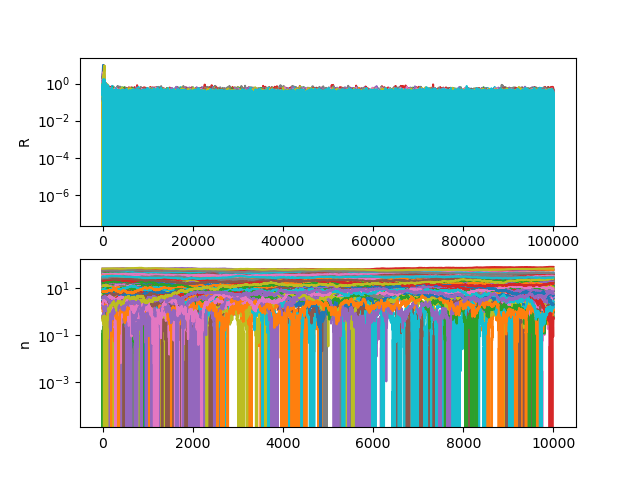

In [270]:
''' Keep only extant species in steady state '''
last_T = 10000
means_full = np.mean(species_traces_full[-last_T:,:],axis=0)
threshold = 1e-3 #in practice, from the plots above
which_species_to_keep = means_full>threshold
species_traces = species_traces_full[-last_T:,which_species_to_keep]

inv_yields = inv_yields_complete[:,which_species_to_keep]
growth_choices = growth_choices_complete[:,which_species_to_keep]

fig,ax = plt.subplots(2,1)
ax[0].plot(resource_traces_full)
ax[0].set_ylabel('R')
ax[0].set_yscale('log')
ax[1].plot(species_traces)
ax[1].set_ylabel('n')
ax[1].set_yscale('log')

In [ ]:
print(species_traces.shape,autocorrelations.shape)

In [ ]:
species_abus.shape

In [ ]:
inv_yields_complete = np.copy(inv_yields)
growth_choices_complete = np.copy(growth_choices)

with open('inv_yields_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(inv_yields_complete,f)
    f.close()
with open('growth_choices_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(growth_choices_complete,f)
    f.close()

In [45]:
import time
if which_option!='B': print('You did not select this option!');
else:

    import functions
    import itertools
    
    how_many_simulations = 20
    nsteps=2000
    inv_yields_complete = np.copy(inv_yields)
    growth_choices_complete = np.copy(growth_choices)
    
    ''' Keep the name "traces" for compatibility with option A, even if these is cross-sample data '''
    species_traces_full = []
    resource_traces_full = []

    time0 = time.time()
    for sim in range(how_many_simulations):
        species_abus = np.random.random(N_species)
        resource_abus = np.random.random(N_resources)
        if sim%1==0: print('{:.3f}%, {:.3f} s'.format(sim/how_many_simulations*100,time.time()-time0))
        
        res_noise_weights = 1e-5#np.linspace(1e-5,1e-1,N_resources) #this way there are different noise levels for different resource-mediated interactions
        
        for step in range(nsteps):
            # if step%1000==0: print('{:.3f}%'.format(step/nsteps*100))
            
            ''' Growth rates '''
            growth_rates,total_growth_rate_per_species = species_growth_rates(resource_abus,species_abus,
                         growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                        )
        
            
            
            d_res = d_resources(resource_abus,species_abus,
                       entry_rates,
                                total_growth_rate_per_species,
                       inv_yields)-resource_abus*dilution
        
            
            d_sp = d_species(species_abus,growth_rates)-species_abus*dilution+1e-8
            
            species_abus += d_sp*dt+species_abus*np.random.normal(0,1e-1,size=(N_species))*np.sqrt(dt)
            resource_abus += d_res*dt#+np.random.normal(0,1,size=(N_resources))*np.sqrt(dt)
            resource_abus[resource_abus<1e-10] = 1e-10
            species_abus[species_abus<1e-10] = 1e-10
        species_traces_full.append(np.copy(species_abus))
        resource_traces_full.append(np.copy(resource_abus))
    print('Time take: {:.3f} s'.format(time.time()-time0))
    
species_traces_full = np.array(species_traces_full)
resource_traces_full = np.array(resource_traces_full)

0.000%, 0.000 s
5.000%, 4.349 s
10.000%, 8.666 s
15.000%, 13.021 s
20.000%, 17.460 s
25.000%, 21.786 s
30.000%, 26.096 s
35.000%, 30.608 s
40.000%, 34.889 s
45.000%, 39.132 s


KeyboardInterrupt: 

In [ ]:
with open('species_traces_full.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(species_traces_full,f)
    f.close()
with open('resource_traces_full.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(resource_traces_full,f)
    f.close()


In [244]:
dataset_name

16

In [245]:
with open('species_traces_full.{}.dat'.format(dataset_name),'rb') as f:
    species_traces_full = pickle.load(f)
    f.close()
with open('resource_traces_full.{}.dat'.format(dataset_name),'rb') as f:
    resource_traces_full = pickle.load(f)
    f.close()

with open('inv_yields_complete.{}.dat'.format(dataset_name),'rb') as f:
    inv_yields_complete = pickle.load(f)
    f.close()
with open('growth_choices_complete.{}.dat'.format(dataset_name),'rb') as f:
    growth_choices_complete = pickle.load(f)
    f.close()

FileNotFoundError: [Errno 2] No such file or directory: 'inv_yields_complete.16.dat'

In [246]:
species_traces_full.shape

(100, 20)

In [247]:
species_traces_full = np.array(species_traces_full)
resource_traces_full = np.array(resource_traces_full)

Text(0.5, 0, 'Sample')

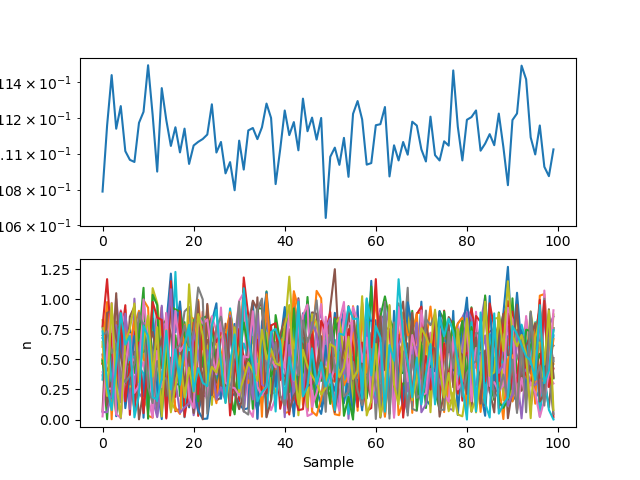

In [250]:
plt.close('all')
%matplotlib widget
fig,ax = plt.subplots(2,1)
ax[0].plot(resource_traces_full)
ax[0].set_ylabel('R')
ax[1].plot(species_traces_full)
ax[1].set_ylabel('n')
# ax[1].set_yscale('log')
ax[0].set_yscale('log')
ax[1].set_xlabel('Sample')

In [ ]:
''' Keep only extant species across samples '''
means_full = np.mean(species_traces_full,axis=0)
threshold = 1e-3 #in practice, from the plots above
which_species_to_keep = means_full>threshold
species_traces = species_traces_full[:,which_species_to_keep]

inv_yields = inv_yields_complete[:,which_species_to_keep]
growth_choices = growth_choices_complete[:,which_species_to_keep]

fig,ax = plt.subplots(2,1)
ax[0].plot(resource_traces_full)
ax[0].set_ylabel('R')
ax[0].set_yscale('log')
ax[1].plot(species_traces)
ax[1].set_ylabel('n')
ax[1].set_yscale('log')

In [ ]:
np.shape(species_traces_full)

## Perform simulations

Simulations are performed in parallel in the "functions.py" script.

# Data Analysis

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39576\2036159133.py:131: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm,shrink=1.0,pad = 0.1,location='right')


There is a factor 1/(1-r) correcting the empirical eigenvalues to match the theoretical predictions. 
 This comes from random matrix theory and the expression can be found in Cocco and Monasson"s textbook on statistical inference.


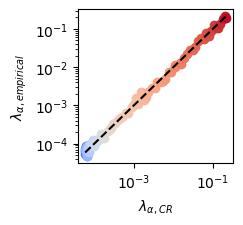

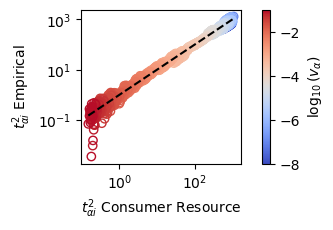

In [8]:

plt.close('all')
%matplotlib inline
plt.close('all')
# %matplotlib widget
fig,ax = plt.subplots()
plt.close('all')
# folder_names = ['linear_sigma_20_species','log_sigma_20_species','linear_sigma_30_species']
# folder_names = ['other']
folder_names = ['other_r20_logsigma']
xi_i_sq_list = []
empirical_xi_i_sq_list = []
for folder_name in folder_names:
    lambdas_theory = []
    lambdas_measured = []
    ratios = []
    if 'linear' in folder_name:
        sigmas = np.linspace(1e-4,10,100) #linear sigma
    if 'log_' in folder_name:
        sigmas  = np.logspace(-4,1,100,base=10)
    if 'other' in folder_name:
        # nat_scale = 20*0.1
        # sigmas = np.sqrt(np.linspace(1e-8,nat_scale,100))
        # sigmas = np.sqrt(np.linspace(1e-8,1,300))
        sigmas= np.sqrt(np.logspace(-8,-1,100,base=10)) 
    
    for dataset_name,sigma in enumerate(sigmas):
        try:
            with open('{}/species_traces_full.{}.dat'.format(folder_name,dataset_name),'rb') as f:
                species_traces_full = pickle.load(f)
                M,N = np.shape(species_traces_full)
                r=N/M
                # print(r)
                f.close()
        except:
            continue
            
        species_traces = np.copy(species_traces_full)
        with open('{}/resource_traces_full.{}.dat'.format(folder_name,dataset_name),'rb') as f:
            resource_traces_full = pickle.load(f)
            f.close()
    
        resource_traces = np.copy(resource_traces_full)
        
        occupancy = np.array(np.sum(species_traces_full>0,axis=0))
        
        data_nonrescaled = np.copy(species_traces)
        
        ''' Rescale abundances by their own standard deviation, as in z-scoring but without subtracting the mean '''
        data  = (data_nonrescaled-np.mean(data_nonrescaled,axis=0)[None,:])/np.std(data_nonrescaled,axis=0)[None,:] #rescale data to z-scored abundances
        
        cov_matrix = np.corrcoef(data.T)
        
        true_eigvals,true_eigvects = np.linalg.eigh(cov_matrix)
        
        argsorted_true_eigvals = np.argsort(true_eigvals)
        true_eigvals=true_eigvals[argsorted_true_eigvals]
        true_eigvects = true_eigvects[:,argsorted_true_eigvals]
        
        true_eigvals = (true_eigvals)
        true_eigvects = (true_eigvects)
        
        #### Use the fact that lambda_emp = 1+s+r+r/s = lambda_true+r+r/s, where lambda_true = 1+s, to infer lambda_true from the empirical eigenvalue
        lambda_empirical_corrected = true_eigvals[0]/(1-r)
        
        ################################# NEW DERIVATION #########################
        v_i = 1e-6 #variance in the noise of species dynamics
        v_alpha = sigma**2 #variance in the noise of resource dynamics
        T_alpha = 0.5*(v_alpha+N*v_i)
        sigma_i = np.std(data_nonrescaled,axis=0) #std of true species abundances across simulations
        sigma_alpha = np.std(resource_traces_full) #std of true resource abundances across simulations
        Y_i = 1 #yields are 1 in all simulations
        dilution = 0.1
        xi_i_sq = (sigma_i/Y_i)**2/(sigma_alpha**2+T_alpha/dilution)
        empirical_xi_i_sq = (1/lambda_empirical_corrected-1)*true_eigvects[:,0]**2

        

        xi_i_sq_list.append(xi_i_sq)
        empirical_xi_i_sq_list.append(empirical_xi_i_sq)
        
        lambda_theory = 1/(1+np.sum(xi_i_sq)) 
        
        lambdas_theory.append(lambda_theory)
        lambdas_measured.append(lambda_empirical_corrected)
    
    lambdas_theory = np.array(lambdas_theory)
    lambdas_measured = np.array(lambdas_measured)

    ratios = np.array(ratios)


cmap = plt.get_cmap('coolwarm')
fig,ax = plt.subplots(figsize=(2,2))
ax.plot(np.linspace(np.min(lambdas_theory),np.max(lambdas_theory),100),
        np.linspace(np.min(lambdas_theory),np.max(lambdas_theory),100),'k--',zorder=10)
ax.set_yscale('log'); ax.set_xscale('log')
for i in range(len(sigmas)):
    ax.scatter(lambdas_theory[i],
               lambdas_measured[i],
               facecolor= cmap(i/len(sigmas))
              )
    # ax.boxplot(lambdas_measured.T,
    #            positions=lambdas_theory)
    # ax.axhline(MP_min)
ax.set_xlabel(r'$\lambda_{\alpha,CR}$')
ax.set_ylabel(r'$\lambda_{\alpha,empirical}$')
plt.savefig('lambda_empirical_vs_theoretical_{}.svg'.format(folder_name),format='svg',transparent=True)
plt.savefig('lambda_empirical_vs_theoretical_{}.png'.format(folder_name),format='png',dpi=300,transparent=True)


fig,ax = plt.subplots(figsize=(2.75,2))
ax.plot(np.linspace(np.min(xi_i_sq_list),np.max(xi_i_sq_list),100),
        np.linspace(np.min(xi_i_sq_list),np.max(xi_i_sq_list),100),'k--',zorder=10)
ax.set_xscale('log');ax.set_yscale('log')

for i in range(len(sigmas)):
    ax.scatter(xi_i_sq_list[i],
               empirical_xi_i_sq_list[i],
              facecolor='none',
               edgecolor = cmap(i/len(sigmas)))
    
ax.set_xlabel(r'$t_{\alpha i}^2$ Consumer Resource')
ax.set_ylabel(r'$t_{\alpha i}^2$ Empirical')
''' Plot the colorbar '''
import matplotlib as mpl
cmap = plt.cm.coolwarm
norm = mpl.colors.Normalize(vmin=np.min(np.log10(sigmas**2)),
                            vmax = np.max(np.log10(sigmas**2)))
sm = mpl.cm.ScalarMappable(cmap=cmap,norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm,shrink=1.0,pad = 0.1,location='right')
cbar.set_label(r'$\log_{10}(v_\alpha)$',)
plt.savefig('pattern_entries_empirical_vs_theoretical_{}.svg'.format(folder_name),format='svg',transparent=True)
plt.savefig('pattern_entries_empirical_vs_theoretical_{}.png'.format(folder_name),format='png',dpi=300,transparent=True)

print('There is a factor 1/(1-r) correcting the empirical eigenvalues to match the theoretical predictions. \n This comes from random matrix theory and the expression can be found in Cocco and Monasson"s textbook on statistical inference.')